In [374]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [375]:
df = pd.read_csv('wdi_poverty_panel_clean.csv')



In [376]:
df.head()

,country_name,country_code,year,electricity_access,agri_value_added,health_expenditure,fdi_inflows,gdp_growth,gdp_per_capita,education_expenditure,...,urban_population,reg_europe_and_central_asia,reg_latin_america_and_caribbean,reg_middle_east_north_africa_afghanistan_and_pakistan,reg_north_america,reg_south_asia,reg_sub_saharan_africa,income_group_Low income,income_group_Lower middle income,income_group_Upper middle income
0,Albania,ALB,2002,99.4,19.763916,5.598027,2.990031,4.628396,1479.838846,3.002530,...,43.152042,1,0,0,0,0,0,0,0,1
1,Albania,ALB,2005,99.4,17.124718,5.662162,3.178998,5.130822,2741.721365,3.200240,...,45.993767,1,0,0,0,0,0,0,0,1
2,Albania,ALB,2008,100.0,15.422100,5.444217,9.406653,6.907062,4498.504868,4.623305,...,49.385070,1,0,0,0,0,0,0,0,1
3,Albania,ALB,2012,99.9,17.591369,6.085047,7.495975,0.984130,4280.933163,3.295340,...,53.863755,1,0,0,0,0,0,0,0,1
4,Albania,ALB,2014,100.0,19.237759,6.358841,8.648466,2.240227,4793.597511,3.181777,...,54.732581,1,0,0,0,0,0,0,0,1


In [377]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 26 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   country_name                                           1671 non-null   object 
 1   country_code                                           1671 non-null   object 
 2   year                                                   1671 non-null   int64  
 3   electricity_access                                     1671 non-null   float64
 4   agri_value_added                                       1671 non-null   float64
 5   health_expenditure                                     1671 non-null   float64
 6   fdi_inflows                                            1671 non-null   float64
 7   gdp_growth                                             1671 non-null   float64
 8   gdp_per_capita                                  

In [378]:
target_col = 'poverty_ratio'

In [379]:
os.makedirs('images', exist_ok=True)

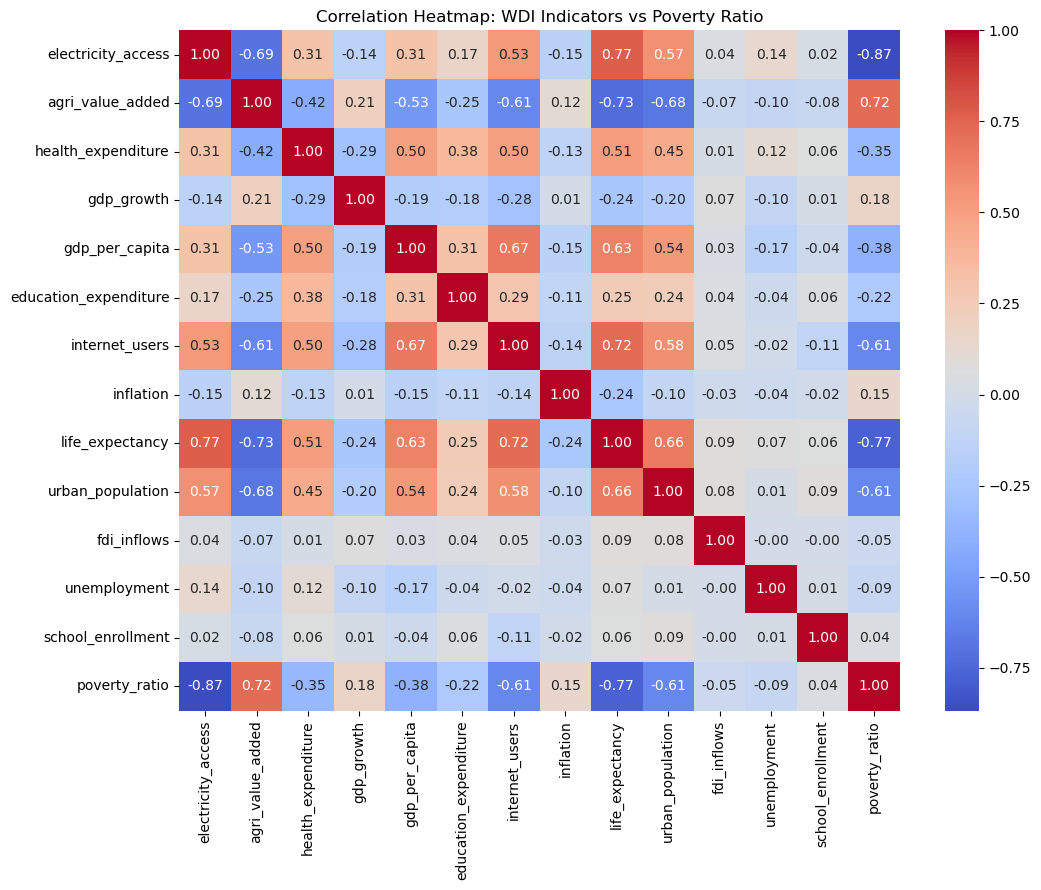

In [410]:
# Correlation heatmap
corr_df = pd.read_csv('wdi_poverty_panel_clean.csv')

continuous_cols = ['electricity_access', 'agri_value_added', 'health_expenditure',
                   'gdp_growth', 'gdp_per_capita', 'education_expenditure',
                   'internet_users', 'inflation', 'life_expectancy',
                   'urban_population', 'fdi_inflows', 'unemployment',
                   'school_enrollment', 'poverty_ratio']

corr = corr_df[continuous_cols].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap: WDI Indicators vs Poverty Ratio')
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation heatmap: This shows how strongly each indicator relates to poverty, from -1 (opposite directions) to +1 (move together). Electricity access is the best negative indicator at -0.87 and life expectancy at -0.77, meaning that improvements in infrastructure and health lead to a decline in poverty, while agricultural share of GDP is the best positive indicator (+0.72), meaning that economies that are more agriculture-oriented tend to be poorer. School enrollment is almost zero and a negligible contribution as are FDI and unemployment, so they are to be possibly removed. Some predictors are also highly correlated in their relationships (life expectancy and electricity access is +0.77); they seem to have some level of redundancy which can be considered for later.

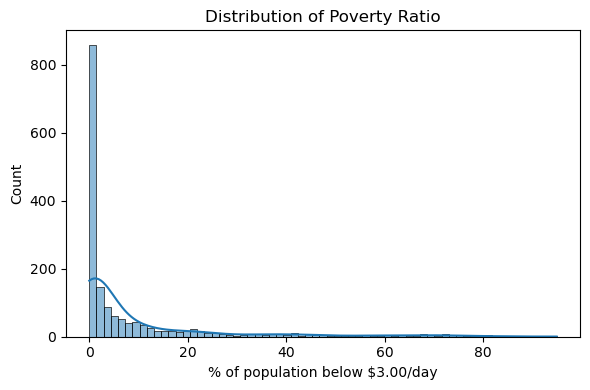

In [381]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.histplot(df[target_col], kde=True)
plt.title('Distribution of Poverty Ratio')
plt.xlabel('% of population below $3.00/day')
plt.tight_layout()
plt.savefig('images/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


Target Distribution: This indicates the distribution of the poverty_ratio across all observations. It is very skewed to the right, with lots of country-years that have low poverty, and a long tail of country-years with high poverty. This skew is important to note, as linear regression is based on a balanced spread, suggesting standardization of the data and possibly a log transformation may help.

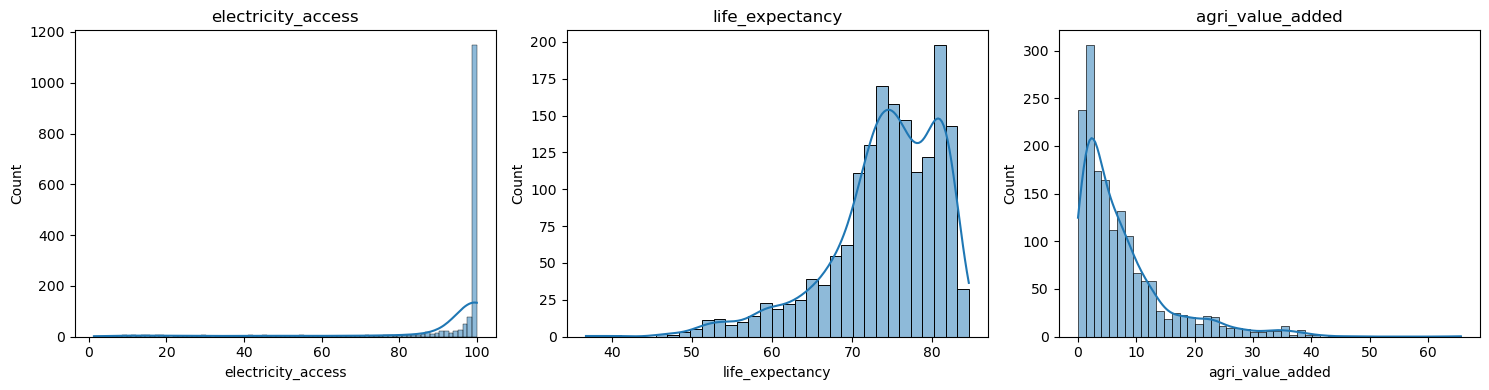

In [382]:
# Top 3 predictor distributions (most correlated with target)
top_features = corr[target_col].abs().sort_values(ascending=False).index[1:4]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feature in zip(axes, top_features):
    sns.histplot(df[feature], kde=True, ax=ax)
    ax.set_title(feature)
plt.tight_layout()
plt.savefig('images/predictor_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


Top predictor distributions: These illustrate the three most poverty-related indicators. They are all warped and have different scales and ranges, and therefore need to be standardized so that no one one variable is at a higher point simply due to raw number. They also allow for detection of any extreme outliers early on so that they do not affect the fit of the model.

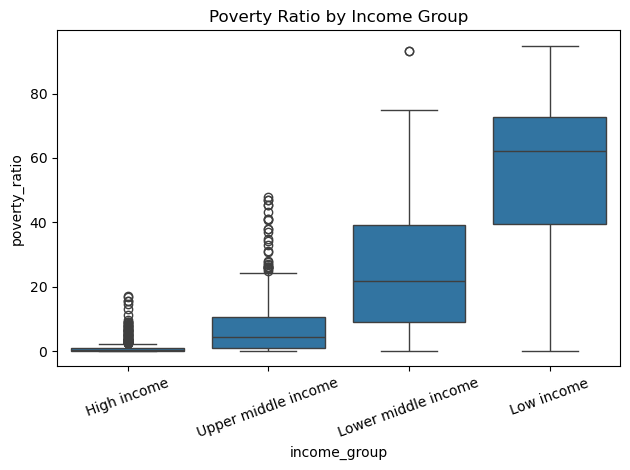

In [383]:
# Boxplot: poverty by income group (categorical feature)
plot_df = pd.read_csv('plot_income_region.csv')
income_order = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']
sns.boxplot(data=plot_df, x='income_group', y='poverty_ratio', order=income_order)
plt.title('Poverty Ratio by Income Group')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('images/poverty_by_income.png', dpi=150, bbox_inches='tight')
plt.show()


In [384]:
# Drop near-zero-correlation predictors (justified by heatmap)
low_signal = ['school_enrollment', 'fdi_inflows', 'unemployment']

In [385]:
# Drop income_group dummies (leakage: derived from GNI, like poverty itself)
income_cols = [c for c in df.columns if c.startswith('income_group')]  #
df = df.drop(columns=low_signal + income_cols)

In [386]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 20 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   country_name                                           1671 non-null   object 
 1   country_code                                           1671 non-null   object 
 2   year                                                   1671 non-null   int64  
 3   electricity_access                                     1671 non-null   float64
 4   agri_value_added                                       1671 non-null   float64
 5   health_expenditure                                     1671 non-null   float64
 6   gdp_growth                                             1671 non-null   float64
 7   gdp_per_capita                                         1671 non-null   float64
 8   education_expenditure                           

In [387]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 20 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   country_name                                           1671 non-null   object 
 1   country_code                                           1671 non-null   object 
 2   year                                                   1671 non-null   int64  
 3   electricity_access                                     1671 non-null   float64
 4   agri_value_added                                       1671 non-null   float64
 5   health_expenditure                                     1671 non-null   float64
 6   gdp_growth                                             1671 non-null   float64
 7   gdp_per_capita                                         1671 non-null   float64
 8   education_expenditure                           

In [388]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [389]:
# Separate features (X) from target (y), dropping non-predictive columns
X = df.drop(columns=['country_name', 'country_code', 'year', 'poverty_ratio'])
y = df['poverty_ratio']


In [390]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [391]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [392]:
X_train_scaled.shape

(1336, 16)

In [393]:
X_test_scaled.shape

(335, 16)

In [394]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [395]:
# 1. Closed-form Linear Regression 
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_mse = mean_squared_error(y_test, lr.predict(X_test_scaled))

In [396]:
# 2. Linear Regression via Gradient Descent (SGD)

sgd = SGDRegressor(max_iter=1, warm_start=True, random_state=42, learning_rate='constant', eta0=0.01)
n_epochs = 100
train_losses, test_losses = [], []
for epoch in range(n_epochs):
    sgd.fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))
sgd_mse = test_losses[-1]


c:\Users\tenio\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\tenio\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\tenio\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\tenio\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\tenio\anaconda3\Lib\site-packages\sklearn\linea

In [397]:
# 3. Random Forest 
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)
rf_mse = mean_squared_error(y_test, rf.predict(X_test_scaled))


In [398]:
# 4. Decision Tree 
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
dt_mse = mean_squared_error(y_test, dt.predict(X_test_scaled))


In [399]:
# Predict on a single row from the test set 
sample_idx = 0
single_row = X_test_scaled[sample_idx].reshape(1, -1)  # one row, reshaped for sklearn

predicted = rf.predict(single_row)[0]        # using best model (Random Forest)
actual = y_test.iloc[sample_idx]

print(f'Predicted poverty ratio: {predicted:.2f}%')
print(f'Actual poverty ratio:    {actual:.2f}%')
print(f'Difference:              {abs(predicted - actual):.2f}%')

Predicted poverty ratio: 5.02%
Actual poverty ratio:    5.00%
Difference:              0.02%


In [400]:
# Compare all four on final loss -
results = {
    'Linear Regression': lr_mse,
    'SGD (Gradient Descent)': sgd_mse,
    'Random Forest': rf_mse,
    'Decision Tree': dt_mse,
}
for name, mse in sorted(results.items(), key=lambda x: x[1]):
    print(f'{name:25s} MSE={mse:7.3f}  RMSE={np.sqrt(mse):6.3f}')

Random Forest             MSE= 19.289  RMSE= 4.392
Linear Regression         MSE= 36.142  RMSE= 6.012
SGD (Gradient Descent)    MSE= 39.281  RMSE= 6.267
Decision Tree             MSE= 48.401  RMSE= 6.957


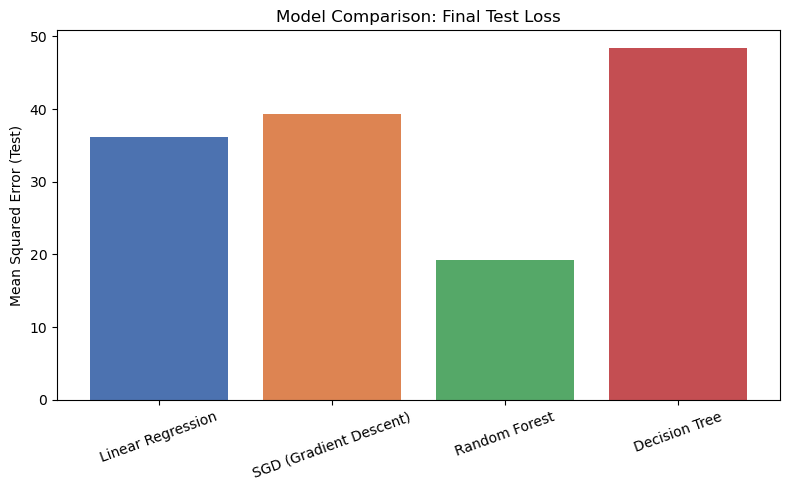

In [401]:
plt.figure(figsize=(8, 5))
names = list(results.keys())
mses = [results[n] for n in names]
plt.bar(names, mses, color=['#4c72b0', '#dd8452', '#55a868', '#c44e52'])
plt.ylabel('Mean Squared Error (Test)')
plt.title('Model Comparison: Final Test Loss')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

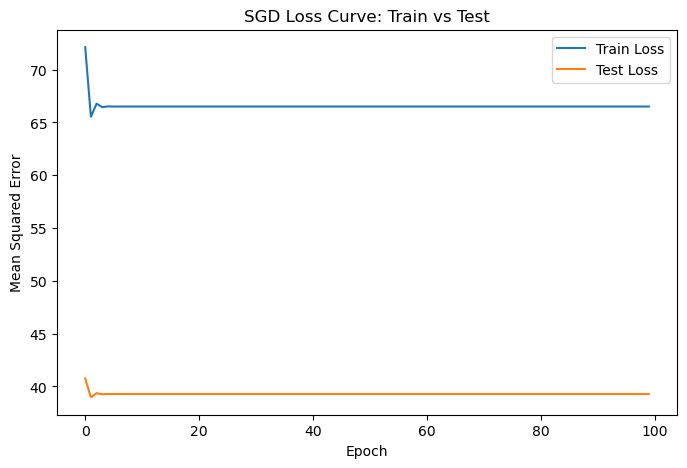

In [402]:
# Loss curve (train vs test)
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('SGD Loss Curve: Train vs Test')
plt.legend()
plt.savefig('images/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

c:\Users\tenio\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


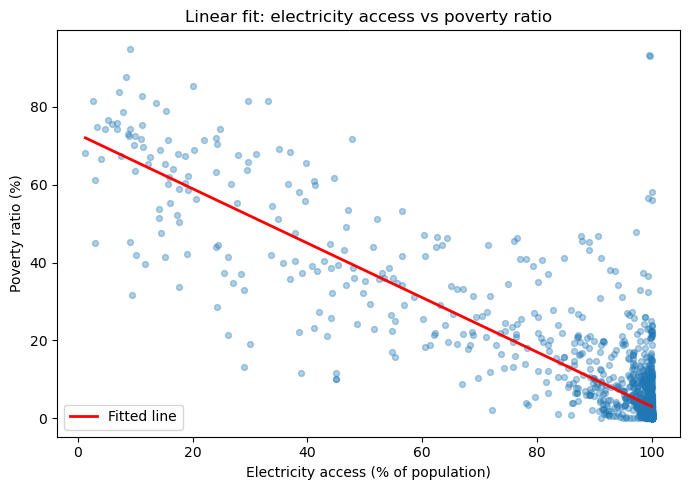

In [403]:
# 1. Where the line passes through the data (single strongest predictor)
from sklearn.linear_model import LinearRegression

simple_lr = LinearRegression().fit(df[['electricity_access']], df['poverty_ratio'])
x_line = np.linspace(df['electricity_access'].min(), df['electricity_access'].max(), 100)
y_line = simple_lr.predict(x_line.reshape(-1, 1))

plt.figure(figsize=(7, 5))
plt.scatter(df['electricity_access'], df['poverty_ratio'], alpha=0.35, s=18)
plt.plot(x_line, y_line, 'r-', lw=2, label='Fitted line')
plt.xlabel('Electricity access (% of population)')
plt.ylabel('Poverty ratio (%)')
plt.title('Linear fit: electricity access vs poverty ratio')
plt.legend()
plt.tight_layout()
plt.savefig('images/best_fit_line.png', dpi=150, bbox_inches='tight')
plt.show()


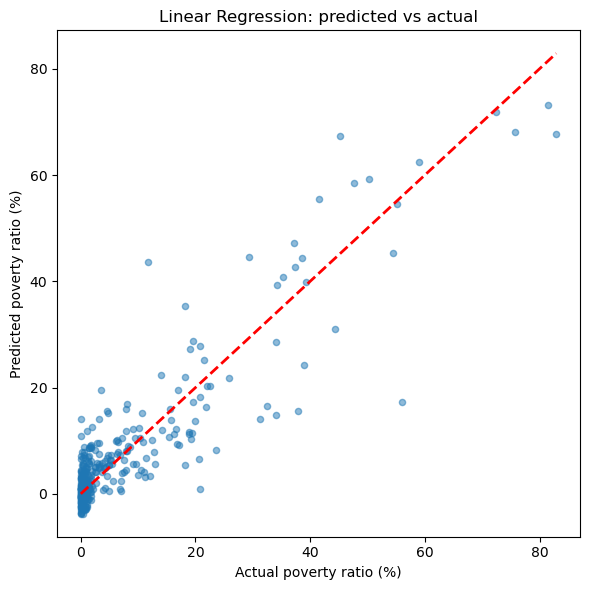

In [404]:
# 2. Full model: predicted vs actual
lr_preds = lr.predict(X_test_scaled)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, lr_preds, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual poverty ratio (%)')
plt.ylabel('Predicted poverty ratio (%)')
plt.title('Linear Regression: predicted vs actual')
plt.tight_layout()
plt.savefig('images/predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()


In [405]:
import joblib

# Save the best model (Random Forest) and the scaler together
joblib.dump(rf, '../API/best_model.pkl')
joblib.dump(scaler, '../API/scaler.pkl')
joblib.dump(list(X.columns), '../API/feature_names.pkl')



['../API/feature_names.pkl']

In [406]:
# Also save the feature order, so the API feeds inputs in the right sequence
feature_names = list(X.columns)
joblib.dump(feature_names, '../API/feature_names.pkl')

print('Saved:', feature_names)

Saved: ['electricity_access', 'agri_value_added', 'health_expenditure', 'gdp_growth', 'gdp_per_capita', 'education_expenditure', 'internet_users', 'inflation', 'life_expectancy', 'urban_population', 'reg_europe_and_central_asia', 'reg_latin_america_and_caribbean', 'reg_middle_east_north_africa_afghanistan_and_pakistan', 'reg_north_america', 'reg_south_asia', 'reg_sub_saharan_africa']


In [407]:
print([c for c in df.columns if c.startswith('reg_')])

['reg_europe_and_central_asia', 'reg_latin_america_and_caribbean', 'reg_middle_east_north_africa_afghanistan_and_pakistan', 'reg_north_america', 'reg_south_asia', 'reg_sub_saharan_africa']


In [408]:
import joblib
print(joblib.load('../API/feature_names.pkl'))

['electricity_access', 'agri_value_added', 'health_expenditure', 'gdp_growth', 'gdp_per_capita', 'education_expenditure', 'internet_users', 'inflation', 'life_expectancy', 'urban_population', 'reg_europe_and_central_asia', 'reg_latin_america_and_caribbean', 'reg_middle_east_north_africa_afghanistan_and_pakistan', 'reg_north_america', 'reg_south_asia', 'reg_sub_saharan_africa']
